## ***The notebook aims to investigate the impact of remote work on mental health issues.***

<a id="A"></a>
<!-- Rectangular gradient style with vibrant and prominent title -->
<div style="text-align:center; 
            padding:40px; 
            margin:20px 0; 
            font-size:220%;  
            font-family:Georgia, sans-serif; 
            color:#F7ECE1; 
            background: linear-gradient(135deg, #C4D7FF, #FFD7C4, #FFF4B5); 
            border-left: 8px solid #C4D7FF; 
            border-radius: 30px; 
            box-shadow: 0 4px 10px rgba(0, 0, 0, 0.15); 
            width: 70%; 
            margin-left: auto; 
            margin-right: auto;">
  <b style="color: #FFFFFF; 
            font-size: 120%; 
            font-weight: bold;
            text-shadow: 1px 1px 2px rgba(0,0,0,0.2), 2px 2px 4px rgba(255,255,255,0.4);">
      About Dataset
  </b>
</div>



### **Columns:**

1. Employee_ID: Unique identifier for each employee.
2. Age: Age of the employee.
3. Gender: Gender of the employee.
4. Job_Role: Current role of the employee.
5. Industry: Industry they work in.
6. Work_Location: Whether they work remotely, hybrid, or onsite.
7. Stress_Level: Their self-reported level of stress.
8. Mental_Health_Condition: Any mental health condition reported (Anxiety, Depression, etc.).
9. Social_Isolation_Rating: A self-reported rating (1-5) on how isolated they feel.
10. Satisfaction_with_Remote_Work: How satisfied they are with remote work arrangements (Satisfied, Neutral, Unsatisfied).

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
#loading dataset
df=pd.read_csv("/Users/huongle/Documents/GitHub/Mind_At_Work_Website/data/mind@work/mental heath dataset/Cleaned_remote_work.csv")

In [3]:
#making dataframe of file
df=pd.DataFrame(df)

In [4]:
df.head()

,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor,North America
3,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,NaN,Poor,Europe
4,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


In [5]:
df.tail()

,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
4995,32,Male,Sales,Consulting,4,Onsite,24,2,5,High,Burnout,Yes,Decrease,4,Neutral,1,Weekly,Average,Asia
4996,39,Female,Sales,Healthcare,27,Onsite,48,15,1,Low,Depression,Yes,Decrease,1,Satisfied,1,NaN,Average,Africa
4997,42,Female,Sales,Healthcare,21,Hybrid,34,1,4,High,Burnout,No,Increase,3,Satisfied,1,Daily,Poor,Oceania
4998,27,Female,Sales,Healthcare,26,Remote,58,0,5,Low,NaN,Yes,Increase,3,Unsatisfied,4,Daily,Average,Asia
4999,29,Male,HR,IT,30,Onsite,20,15,1,Low,Depression,Yes,No Change,3,Unsatisfied,5,NaN,Poor,Asia


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Age                                5000 non-null   int64 
 1   Gender                             5000 non-null   object
 2   Job_Role                           5000 non-null   object
 3   Industry                           5000 non-null   object
 4   Years_of_Experience                5000 non-null   int64 
 5   Work_Location                      5000 non-null   object
 6   Hours_Worked_Per_Week              5000 non-null   int64 
 7   Number_of_Virtual_Meetings         5000 non-null   int64 
 8   Work_Life_Balance_Rating           5000 non-null   int64 
 9   Stress_Level                       5000 non-null   object
 10  Mental_Health_Condition            3804 non-null   object
 11  Access_to_Mental_Health_Resources  5000 non-null   object
 12  Produc

### You can see a lot of columns that could be a consequence of some other columns. 
### Also, I can see the numeric columns as well as character columns here. 
### The ***Physical Activity*** & ***Mental Health condition*** column has null values only. 

# ***The columns that have null values are both category type. We can fill the null values with MODE but they are great in number, restricting us from filling values with MODE. So we will create another value as 'Not Mentioned' to replace null values***

In [7]:
df['Mental_Health_Condition'].isnull().sum()

1196

In [8]:
df['Physical_Activity'].isnull().sum()

1629

In [9]:
#filling NAN values with Mode of the column
df['Mental_Health_Condition'].fillna('No condition', inplace=True)
df['Physical_Activity'].fillna('No activity', inplace=True)

In [10]:
df['Mental_Health_Condition'].isnull().sum()
df['Mental_Health_Condition'].value_counts()    

Mental_Health_Condition
Burnout         1280
Anxiety         1278
Depression      1246
No condition    1196
Name: count, dtype: int64

In [11]:
df['Physical_Activity'].isnull().sum()
df['Physical_Activity'].value_counts()  

Physical_Activity
Weekly         1755
No activity    1629
Daily          1616
Name: count, dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Age                                5000 non-null   int64 
 1   Gender                             5000 non-null   object
 2   Job_Role                           5000 non-null   object
 3   Industry                           5000 non-null   object
 4   Years_of_Experience                5000 non-null   int64 
 5   Work_Location                      5000 non-null   object
 6   Hours_Worked_Per_Week              5000 non-null   int64 
 7   Number_of_Virtual_Meetings         5000 non-null   int64 
 8   Work_Life_Balance_Rating           5000 non-null   int64 
 9   Stress_Level                       5000 non-null   object
 10  Mental_Health_Condition            5000 non-null   object
 11  Access_to_Mental_Health_Resources  5000 non-null   object
 12  Produc

# We'll explore each column one by one.

In [13]:
df['Age'].unique()

array([32, 40, 59, 27, 49, 31, 42, 56, 30, 33, 47, 51, 36, 45, 26, 43, 53,
       22, 37, 48, 46, 24, 54, 57, 35, 60, 25, 50, 28, 23, 38, 29, 58, 55,
       41, 44, 34, 52, 39])

In [14]:
df['Gender'].value_counts()

Gender
Female               1274
Male                 1270
Prefer not to say    1242
Non-binary           1214
Name: count, dtype: int64

In [15]:
df['Access_to_Mental_Health_Resources'].value_counts()

Access_to_Mental_Health_Resources
No     2553
Yes    2447
Name: count, dtype: int64

In [16]:
df['Company_Support_for_Remote_Work'].value_counts()

Company_Support_for_Remote_Work
3    1077
5     987
2     985
4     984
1     967
Name: count, dtype: int64

In [17]:
df['Hours_Worked_Per_Week'].unique()    

array([47, 52, 46, 32, 35, 39, 51, 54, 24, 57, 48, 26, 21, 45, 59, 44, 37,
       36, 22, 56, 33, 25, 20, 30, 29, 58, 53, 23, 42, 28, 31, 55, 49, 43,
       27, 38, 60, 50, 34, 41, 40])

In [18]:
df['Industry'].value_counts()

Industry
Finance          747
IT               746
Healthcare       728
Retail           726
Education        690
Manufacturing    683
Consulting       680
Name: count, dtype: int64

In [19]:
df['Job_Role'].value_counts()

Job_Role
Project Manager      738
Sales                733
Designer             723
HR                   716
Software Engineer    711
Data Scientist       696
Marketing            683
Name: count, dtype: int64

In [20]:
df['Mental_Health_Condition'].value_counts()    

Mental_Health_Condition
Burnout         1280
Anxiety         1278
Depression      1246
No condition    1196
Name: count, dtype: int64

In [21]:
df['Number_of_Virtual_Meetings'].unique() 

array([ 7,  4, 11,  8, 12,  3,  6, 13,  9,  1, 15, 14, 10,  2,  0,  5])

In [22]:
df['Physical_Activity'].value_counts()  

Physical_Activity
Weekly         1755
No activity    1629
Daily          1616
Name: count, dtype: int64

In [23]:
df['Productivity_Change'].value_counts()

Productivity_Change
Decrease     1737
No Change    1677
Increase     1586
Name: count, dtype: int64

In [24]:
df['Region'].value_counts()

Region
Oceania          867
Africa           860
Europe           840
Asia             829
South America    827
North America    777
Name: count, dtype: int64

In [25]:
df['Satisfaction_with_Remote_Work'].value_counts()  

Satisfaction_with_Remote_Work
Unsatisfied    1677
Satisfied      1675
Neutral        1648
Name: count, dtype: int64

In [26]:
df['Sleep_Quality'].value_counts()  

Sleep_Quality
Good       1687
Poor       1685
Average    1628
Name: count, dtype: int64

In [27]:
df['Social_Isolation_Rating'].value_counts()

Social_Isolation_Rating
2    1066
4    1037
3     992
1     953
5     952
Name: count, dtype: int64

In [28]:
df['Stress_Level'].value_counts()

Stress_Level
High      1686
Medium    1669
Low       1645
Name: count, dtype: int64

In [29]:
df['Work_Life_Balance_Rating'].value_counts()

Work_Life_Balance_Rating
3    1053
1    1023
4     980
5     977
2     967
Name: count, dtype: int64

In [30]:
df['Work_Location'].value_counts()

Work_Location
Remote    1714
Hybrid    1649
Onsite    1637
Name: count, dtype: int64

In [31]:
df['Years_of_Experience'].unique()

array([13,  3, 22, 20, 32, 31, 24,  6,  9, 28, 17,  1,  5, 23, 30, 33, 21,
       11, 34,  4, 29, 27, 10, 18, 14, 26, 12,  7, 25,  8, 15, 35,  2, 19,
       16])

In [32]:
df.columns

Index(['Age', 'Gender', 'Job_Role', 'Industry', 'Years_of_Experience',
       'Work_Location', 'Hours_Worked_Per_Week', 'Number_of_Virtual_Meetings',
       'Work_Life_Balance_Rating', 'Stress_Level', 'Mental_Health_Condition',
       'Access_to_Mental_Health_Resources', 'Productivity_Change',
       'Social_Isolation_Rating', 'Satisfaction_with_Remote_Work',
       'Company_Support_for_Remote_Work', 'Physical_Activity', 'Sleep_Quality',
       'Region'],
      dtype='object')

<Axes: >

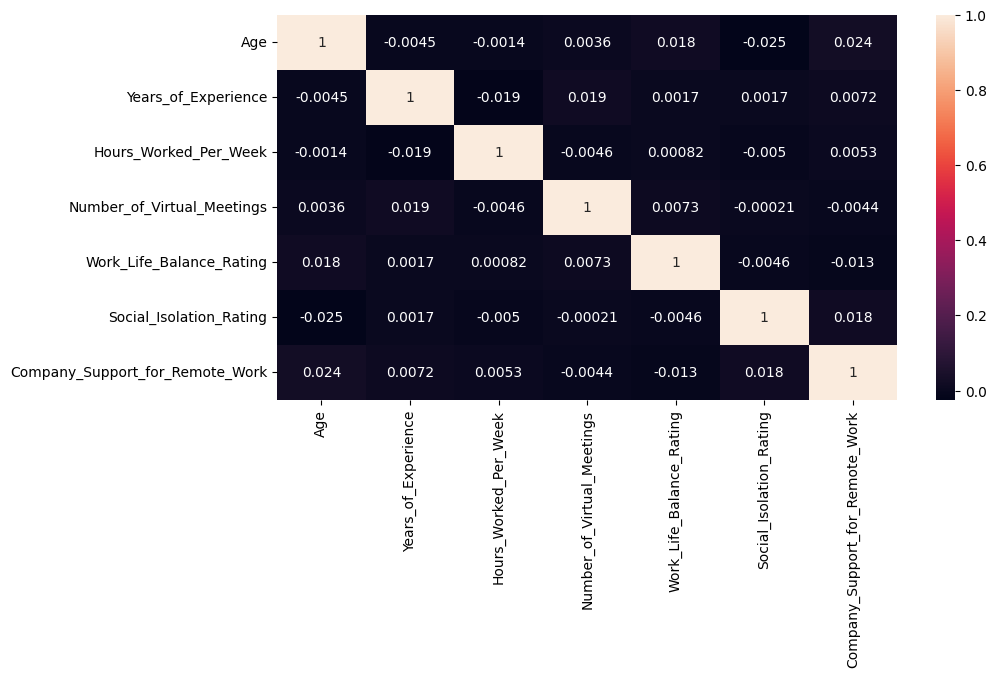

In [34]:
#making heatplot
plt.figure(figsize=(10,5))
numeric_col=['Age','Years_of_Experience','Hours_Worked_Per_Week', 'Number_of_Virtual_Meetings', 
               'Work_Life_Balance_Rating','Social_Isolation_Rating','Company_Support_for_Remote_Work' ]
sns.heatmap(df[numeric_col].corr(), annot=True)

# You can see the numeric column has no relativity but I can tell by observation that the categorical columns must have some relativity. Therefore, we can Encode those columns were choices are limited( usually 2 or 3 choices ). This would give us a chance to analyze more closely with ML models in future.

<a id="A"></a>
<!-- Rectangular gradient style with vibrant and prominent title -->
<div style="text-align:center; 
            padding:40px; 
            margin:20px 0; 
            font-size:220%;  
            font-family:Georgia, sans-serif; 
            color:#F7ECE1; 
            background: linear-gradient(135deg, #C4D7FF, #FFD7C4, #FFF4B5); 
            border-left: 8px solid #C4D7FF; 
            border-radius: 30px; 
            box-shadow: 0 4px 10px rgba(0, 0, 0, 0.15); 
            width: 70%; 
            margin-left: auto; 
            margin-right: auto;">
  <b style="color: #FFFFFF; 
            font-size: 120%; 
            font-weight: bold;
            text-shadow: 1px 1px 2px rgba(0,0,0,0.2), 2px 2px 4px rgba(255,255,255,0.4);">
      Let's Explore Demographics
  </b>
</div>

In [36]:
#Genders included in the study
import plotly.express as px
gender_counts=df['Gender'].value_counts()
fig = px.pie(df, values=gender_counts.values, names=gender_counts.index, color_discrete_sequence=px.colors.sequential.RdBu, title="Genders included in the study")
fig.show()

In [37]:
#Age distribution
import plotly.express as px
age_counts=df['Age'].value_counts().reset_index()
age_counts.columns=['Age', 'Count']
fig = px.bar(age_counts, x='Age',y='Count',
             title='Age distribution',labels={'Age': 'Age', 'Count': 'Count'}, color='Count')
fig.show()

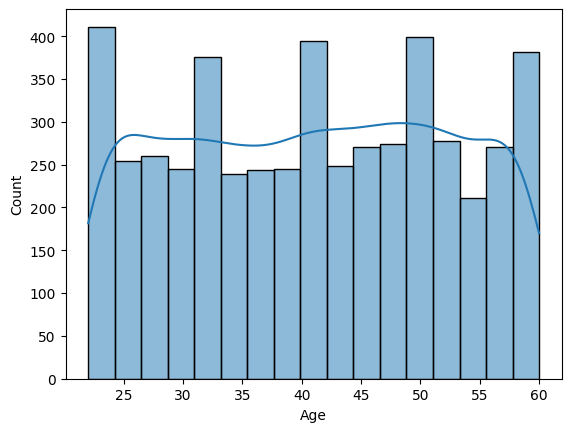

In [38]:
#checking normal distribution
sns.histplot(df['Age'], kde=True)
px.title= ("Age Distribution")
px.xlabel= ("Age")  
px.ylabel= ("Count")    
plt.show()

# ***This is nearly Uniform Ditribution***  

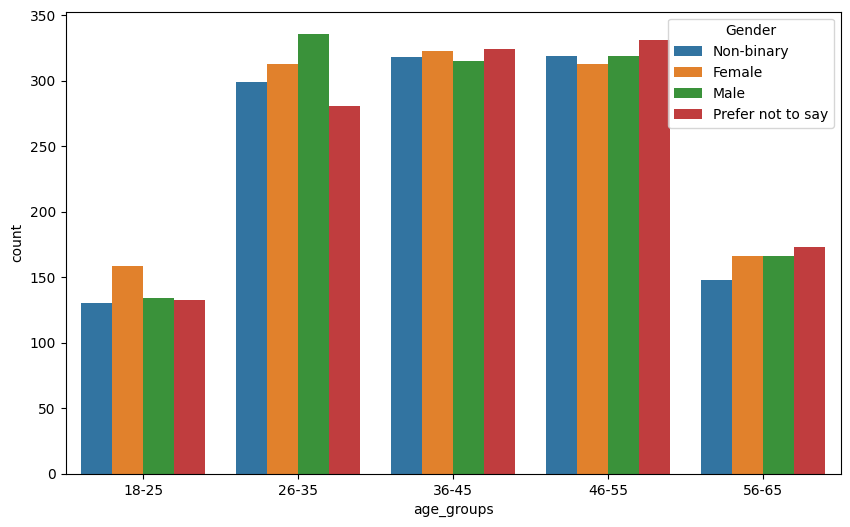

In [39]:
#distribution of age groups and gender
bins=[18,25,35,45,55,65]
labels=['18-25','26-35','36-45','46-55','56-65']

#Renaming the age groups
gender_mapping={0:''}

df['age_groups']=pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='age_groups', hue='Gender')    
plt.title='Distribution of Age'
plt.show()

In [40]:
#stress level by age group

stress_age_counts=df.groupby(['age_groups','Stress_Level']).size().reset_index(name='count')
stress_age_total=df.groupby('age_groups').size().reset_index(name='total')
stress_age_perc=pd.merge(stress_age_counts, stress_age_total, on='age_groups')
stress_age_perc['percentage']=stress_age_perc['count']/stress_age_perc['total']*100
stress_age_perc=stress_age_perc.sort_values(by=['age_groups','Stress_Level'])
print(stress_age_perc)

   age_groups Stress_Level  count  total  percentage
0       18-25         High    181    556   32.553957
1       18-25          Low    192    556   34.532374
2       18-25       Medium    183    556   32.913669
3       26-35         High    410   1229   33.360456
4       26-35          Low    404   1229   32.872254
5       26-35       Medium    415   1229   33.767290
6       36-45         High    438   1280   34.218750
7       36-45          Low    421   1280   32.890625
8       36-45       Medium    421   1280   32.890625
9       46-55         High    425   1282   33.151326
10      46-55          Low    433   1282   33.775351
11      46-55       Medium    424   1282   33.073323
12      56-65         High    232    653   35.528331
13      56-65          Low    195    653   29.862175
14      56-65       Medium    226    653   34.609495


In [63]:
#making dataframe
df_stressage=pd.DataFrame(stress_age_perc)
df_stressage.head()

,age_groups,Stress_Level,count,total,percentage
0,18-25,High,181,556,32.553957
1,18-25,Low,192,556,34.532374
2,18-25,Medium,183,556,32.913669
3,26-35,High,410,1229,33.360456
4,26-35,Low,404,1229,32.872254


In [42]:
fig=px.bar(df_stressage, x='age_groups', y='percentage', color='Stress_Level', barmode='group', title='Stress Level In Different Age Groups')
fig.show()

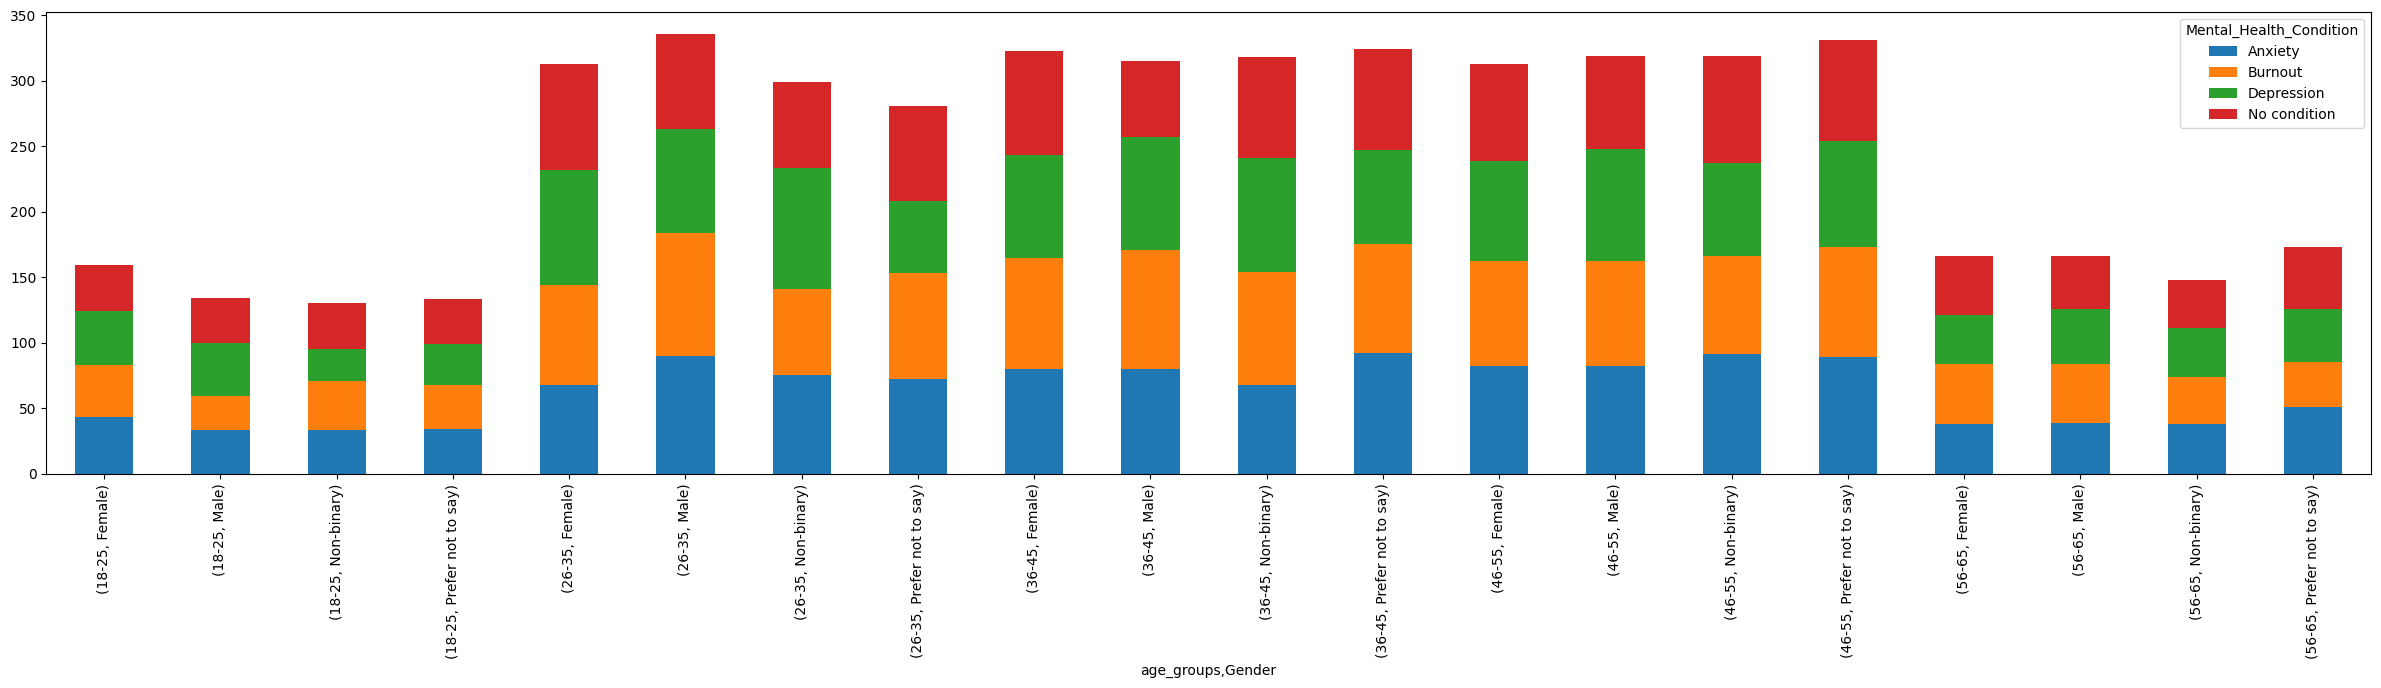

In [43]:
#mental health condition by age group and gender
mental_health_counts=df.groupby(['age_groups','Gender'])['Mental_Health_Condition'].value_counts().unstack().fillna(0)
mental_health_counts.plot(kind='bar', stacked=True, figsize=(30,6))
plt.title='Mnetal Heath Condition by Age and Gender'
plt.show()

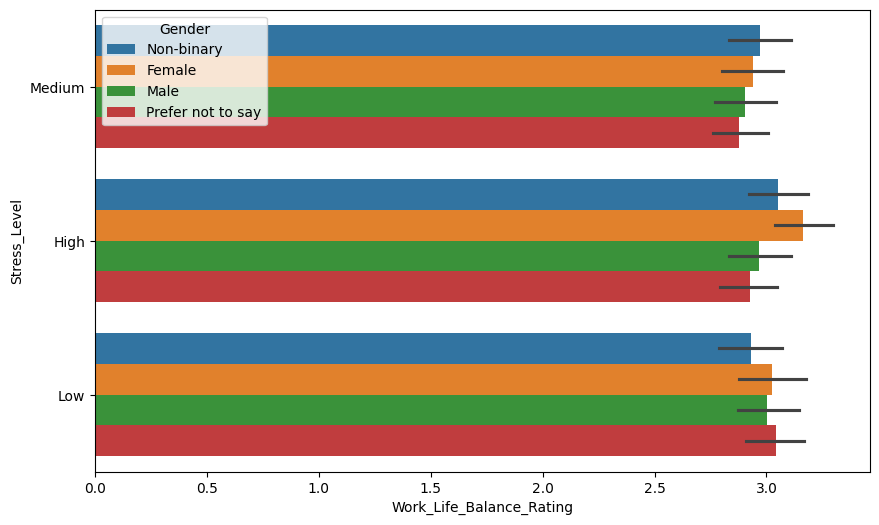

In [44]:
#worklife balance vs stress
plt.figure(figsize=(10,6))  
sns.barplot(x='Work_Life_Balance_Rating', y='Stress_Level', data=df, hue='Gender')
plt.title='Work Life Balance vs Stress Level'
plt.show()

In [45]:
#sleep quality vs stress level
sleep_stress_counts=df.groupby(['Sleep_Quality','Stress_Level']).size().reset_index(name='count')
sleep_stress_total=df.groupby('Sleep_Quality').size().reset_index(name='total')
sleep_stress_perc=pd.merge(sleep_stress_counts, sleep_stress_total, on='Sleep_Quality')
sleep_stress_perc['percentage']=sleep_stress_perc['count']/sleep_stress_perc['total']*100
sleep_stress_perc=sleep_stress_perc.sort_values(by=['Sleep_Quality','Stress_Level'])
print(sleep_stress_perc)

  Sleep_Quality Stress_Level  count  total  percentage
0       Average         High    561   1628   34.459459
1       Average          Low    536   1628   32.923833
2       Average       Medium    531   1628   32.616708
3          Good         High    541   1687   32.068761
4          Good          Low    564   1687   33.432128
5          Good       Medium    582   1687   34.499111
6          Poor         High    584   1685   34.658754
7          Poor          Low    545   1685   32.344214
8          Poor       Medium    556   1685   32.997033


In [46]:
#making dataframe
df_sleepstress=pd.DataFrame(sleep_stress_perc)
df_sleepstress.head()

,Sleep_Quality,Stress_Level,count,total,percentage
0,Average,High,561,1628,34.459459
1,Average,Low,536,1628,32.923833
2,Average,Medium,531,1628,32.616708
3,Good,High,541,1687,32.068761
4,Good,Low,564,1687,33.432128


In [47]:
fig=px.bar(df_sleepstress, x='Sleep_Quality', y='percentage', color='Stress_Level', barmode='group', title='Sleep Qaulity Imapct On stress Level')
fig.show()

<a id="A"></a>
<!-- Rectangular gradient style with vibrant and prominent title -->
<div style="text-align:center; 
            padding:40px; 
            margin:20px 0; 
            font-size:220%;  
            font-family:Georgia, sans-serif; 
            color:#F7ECE1; 
            background: linear-gradient(135deg, #C4D7FF, #FFD7C4, #FFF4B5); 
            border-left: 8px solid #C4D7FF; 
            border-radius: 30px; 
            box-shadow: 0 4px 10px rgba(0, 0, 0, 0.15); 
            width: 70%; 
            margin-left: auto; 
            margin-right: auto;">
  <b style="color: #FFFFFF; 
            font-size: 120%; 
            font-weight: bold;
            text-shadow: 1px 1px 2px rgba(0,0,0,0.2), 2px 2px 4px rgba(255,255,255,0.4);">
      Other Insights
  </b>
</div>

In [48]:
#group data on stress level and industry
industry_stress_counts=df.groupby(['Industry','Stress_Level']).size().reset_index(name='count')
industry_total=df.groupby('Industry').size().reset_index(name='total')
industry_stress_perc=pd.merge(industry_stress_counts, industry_total, on='Industry')
industry_stress_perc['percentage']=industry_stress_perc['count']/industry_stress_perc['total']*100
industry_stress_perc=industry_stress_perc.sort_values(by=['Industry','Stress_Level'])
print(industry_stress_perc)


         Industry Stress_Level  count  total  percentage
0      Consulting         High    219    680   32.205882
1      Consulting          Low    226    680   33.235294
2      Consulting       Medium    235    680   34.558824
3       Education         High    238    690   34.492754
4       Education          Low    205    690   29.710145
5       Education       Medium    247    690   35.797101
6         Finance         High    266    747   35.609103
7         Finance          Low    248    747   33.199465
8         Finance       Medium    233    747   31.191432
9      Healthcare         High    257    728   35.302198
10     Healthcare          Low    231    728   31.730769
11     Healthcare       Medium    240    728   32.967033
12             IT         High    243    746   32.573727
13             IT          Low    263    746   35.254692
14             IT       Medium    240    746   32.171582
15  Manufacturing         High    215    683   31.478770
16  Manufacturing          Low 

In [49]:
#making dataframe
df_stressindus=pd.DataFrame(industry_stress_perc)
df_stressindus.head()

,Industry,Stress_Level,count,total,percentage
0,Consulting,High,219,680,32.205882
1,Consulting,Low,226,680,33.235294
2,Consulting,Medium,235,680,34.558824
3,Education,High,238,690,34.492754
4,Education,Low,205,690,29.710145


In [50]:
#visualizing the dataframe
fig=px.bar(df_stressindus, x='Industry', y='percentage', color='Stress_Level', barmode='group', title='Stress level by Industry')
fig.show()

In [51]:
#group data on mental health and industry
industry_mhealth_counts=df.groupby(['Industry','Mental_Health_Condition']).size().reset_index(name='count')
industry_total=df.groupby('Industry').size().reset_index(name='total')
industry_mhealth_perc=pd.merge(industry_mhealth_counts, industry_total, on='Industry')
industry_mhealth_perc['percentage']=industry_mhealth_perc['count']/industry_mhealth_perc['total']*100
industry_mhealth_perc=industry_mhealth_perc.sort_values(by=['Industry','Mental_Health_Condition'])
print(industry_mhealth_perc)

         Industry Mental_Health_Condition  count  total  percentage
0      Consulting                 Anxiety    178    680   26.176471
1      Consulting                 Burnout    166    680   24.411765
2      Consulting              Depression    172    680   25.294118
3      Consulting            No condition    164    680   24.117647
4       Education                 Anxiety    176    690   25.507246
5       Education                 Burnout    174    690   25.217391
6       Education              Depression    171    690   24.782609
7       Education            No condition    169    690   24.492754
8         Finance                 Anxiety    186    747   24.899598
9         Finance                 Burnout    202    747   27.041499
10        Finance              Depression    179    747   23.962517
11        Finance            No condition    180    747   24.096386
12     Healthcare                 Anxiety    160    728   21.978022
13     Healthcare                 Burnout    191

In [52]:
#making dataframe
df_mentalindus=pd.DataFrame(industry_mhealth_perc)  
df_mentalindus.head()   

,Industry,Mental_Health_Condition,count,total,percentage
0,Consulting,Anxiety,178,680,26.176471
1,Consulting,Burnout,166,680,24.411765
2,Consulting,Depression,172,680,25.294118
3,Consulting,No condition,164,680,24.117647
4,Education,Anxiety,176,690,25.507246


In [53]:
fig=px.bar(df_mentalindus, x='Industry', y='percentage', color='Mental_Health_Condition', barmode='group', title='Mental Health Condition by Industry')
fig.show()

In [54]:
#location impact on satisfaction
loc_satisfaction_counts=df.groupby(['Work_Location','Satisfaction_with_Remote_Work']).size().reset_index(name='count')
loc_satisfaction_total=df.groupby('Work_Location').size().reset_index(name='total')
loc_satisfaction_perc=pd.merge(loc_satisfaction_counts, loc_satisfaction_total, on='Work_Location')
loc_satisfaction_perc['percentage']=loc_satisfaction_perc['count']/loc_satisfaction_perc['total']*100
loc_satisfaction_perc=loc_satisfaction_perc.sort_values(by=['Work_Location','Satisfaction_with_Remote_Work'])
print(loc_satisfaction_perc)

  Work_Location Satisfaction_with_Remote_Work  count  total  percentage
0        Hybrid                       Neutral    539   1649   32.686477
1        Hybrid                     Satisfied    564   1649   34.202547
2        Hybrid                   Unsatisfied    546   1649   33.110976
3        Onsite                       Neutral    506   1637   30.910202
4        Onsite                     Satisfied    592   1637   36.163714
5        Onsite                   Unsatisfied    539   1637   32.926084
6        Remote                       Neutral    603   1714   35.180863
7        Remote                     Satisfied    519   1714   30.280047
8        Remote                   Unsatisfied    592   1714   34.539090


In [55]:
df_locsatisfac=pd.DataFrame(loc_satisfaction_perc)  
df_locsatisfac.head()

,Work_Location,Satisfaction_with_Remote_Work,count,total,percentage
0,Hybrid,Neutral,539,1649,32.686477
1,Hybrid,Satisfied,564,1649,34.202547
2,Hybrid,Unsatisfied,546,1649,33.110976
3,Onsite,Neutral,506,1637,30.910202
4,Onsite,Satisfied,592,1637,36.163714


In [56]:
fig=px.bar(df_locsatisfac, x='Work_Location', y='percentage', color='Satisfaction_with_Remote_Work', barmode='group', title='Work Location Satisfaction')
fig.show()

In [57]:
loc_activity_counts=df.groupby(['Work_Location','Physical_Activity']).size().reset_index(name='count')
loc_activity_total=df.groupby('Work_Location').size().reset_index(name='total')
loc_activity_perc=pd.merge(loc_activity_counts, loc_activity_total, on='Work_Location')
loc_activity_perc['percentage']=loc_activity_perc['count']/loc_activity_perc['total']*100
loc_activity_perc=loc_activity_perc.sort_values(by=['Work_Location','Physical_Activity'])
print(loc_activity_perc)


  Work_Location Physical_Activity  count  total  percentage
0        Hybrid             Daily    515   1649   31.231049
1        Hybrid       No activity    536   1649   32.504548
2        Hybrid            Weekly    598   1649   36.264403
3        Onsite             Daily    515   1637   31.459988
4        Onsite       No activity    550   1637   33.598045
5        Onsite            Weekly    572   1637   34.941967
6        Remote             Daily    586   1714   34.189032
7        Remote       No activity    543   1714   31.680280
8        Remote            Weekly    585   1714   34.130688


In [58]:
df_locactivity=pd.DataFrame(loc_activity_perc)  
df_locactivity.head()   

,Work_Location,Physical_Activity,count,total,percentage
0,Hybrid,Daily,515,1649,31.231049
1,Hybrid,No activity,536,1649,32.504548
2,Hybrid,Weekly,598,1649,36.264403
3,Onsite,Daily,515,1637,31.459988
4,Onsite,No activity,550,1637,33.598045


In [59]:
fig=px.bar(df_locactivity, x='Work_Location', y='percentage', color='Physical_Activity', barmode='group', title='Physical Activity vs Location')
fig.show()


In [60]:
#social isolation in different age groups
social_ages_counts=df.groupby(['Social_Isolation_Rating','age_groups']).size().reset_index(name='count')
social_ages_total=df.groupby('Social_Isolation_Rating').size().reset_index(name='total')
social_ages_perc=pd.merge(social_ages_counts, social_ages_total, on='Social_Isolation_Rating')
social_ages_perc['percentage']=social_ages_perc['count']/social_ages_perc['total']*100
social_ages_perc=social_ages_perc.sort_values(by=['Social_Isolation_Rating','age_groups'])
print(social_ages_perc)

    Social_Isolation_Rating age_groups  count  total  percentage
0                         1      18-25    106    953   11.122770
1                         1      26-35    252    953   26.442812
2                         1      36-45    229    953   24.029381
3                         1      46-55    235    953   24.658972
4                         1      56-65    131    953   13.746065
5                         2      18-25    103   1066    9.662289
6                         2      26-35    251   1066   23.545966
7                         2      36-45    276   1066   25.891182
8                         2      46-55    284   1066   26.641651
9                         2      56-65    152   1066   14.258912
10                        3      18-25    119    992   11.995968
11                        3      26-35    225    992   22.681452
12                        3      36-45    261    992   26.310484
13                        3      46-55    258    992   26.008065
14                       

In [61]:
df_isoage=pd.DataFrame(social_ages_perc)    
df_isoage.head()

,Social_Isolation_Rating,age_groups,count,total,percentage
0,1,18-25,106,953,11.122770
1,1,26-35,252,953,26.442812
2,1,36-45,229,953,24.029381
3,1,46-55,235,953,24.658972
4,1,56-65,131,953,13.746065


In [62]:
fig=px.bar(df_isoage, x='age_groups', y='percentage', color='Social_Isolation_Rating', barmode='group', title='Social Isolation Rating In Age Groups')
fig.show()